# Setup + Load data

#### imports and files

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("final_df_FULL_BACKUP.csv")

print(df.shape)
df.head()

(4078, 84)


,Song,Artist,first_chart_date,last_chart_date,entry_rank,peak_rank,total_weeks,top10_weeks,top40_weeks,avg_rank,...,genre_family_reggae,genre_family_rock,genre_family_stage_and_screen,audio_feature_error,preview_file,tempo_bpm_raw,tempo_bpm_adjusted,tempo_adjustment_reason,days_release_to_chart,days_release_to_peak
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021-06-02,2021-06-23,19,19,4,0,2,54.250000,...,0.005238,0.152280,0.011177,NaN,preview_clips/olivia_rodrigo__1_step_forward_3...,172.265625,86.132812,halved_145_180_likely_double_time,11.0,11.0
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005-01-05,2005-07-20,2,2,39,12,24,19.448276,...,0.003168,0.007899,0.000968,NaN,preview_clips/ciara_featuring_missy_elliott__1...,116.173401,116.173401,unchanged,-6639.0,-6639.0
2,"""1, 2, 3, 4""",Plain White T's,2009-02-04,2009-06-17,91,34,20,0,5,47.800000,...,0.023637,1.199483,0.002437,NaN,preview_clips/plain_white_t_s__1_2_3_4__160588...,89.632843,89.632843,unchanged,133.0,238.0
3,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019-10-16,2020-05-06,4,4,30,14,28,15.933333,...,0.016751,0.140071,0.005422,NaN,preview_clips/dan_shay_justin_bieber__10_000_h...,178.205811,178.205811,kept_high_bpm_strong_electronic_or_rock,11.0,11.0
4,"""Awful, Beautiful Life""",Darryl Worley,2005-01-05,2005-03-23,49,30,20,0,2,63.583333,...,0.000909,0.723153,0.004464,NaN,preview_clips/darryl_worley__awful_beautiful_l...,112.451279,112.451279,unchanged,369.0,383.0


In [66]:
pd.set_option('display.max_rows', 100)


#### Create Era Labels

In [68]:
df["first_chart_date"] = pd.to_datetime(df["first_chart_date"], errors="coerce")
df["apple_release_date"] = pd.to_datetime(df["apple_release_date"], errors="coerce")

df["entry_year"] = df["first_chart_date"].dt.year
df["release_year"] = df["apple_release_date"].dt.year

df["billboard_era"] = np.where(
    df["entry_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

df["audio_era"] = np.where(
    df["release_year"] < 2018,
    "Pre TikTok",
    "Post TikTok"
)

df[["Song", "Artist", "entry_year", "release_year", "billboard_era", "audio_era"]].head()

,Song,Artist,entry_year,release_year,billboard_era,audio_era
0,"""1 Step Forward, 3 Steps Back""",Olivia Rodrigo,2021,2021.0,Post TikTok,Post TikTok
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,2005,2023.0,Pre TikTok,Post TikTok
2,"""1, 2, 3, 4""",Plain White T's,2009,2008.0,Pre TikTok,Pre TikTok
3,"""10,000 Hours""",Dan + Shay & Justin Bieber,2019,2019.0,Post TikTok,Post TikTok
4,"""Awful, Beautiful Life""",Darryl Worley,2005,2004.0,Pre TikTok,Pre TikTok


# AUDIO PCA + CLUSTERING

3. Audio Feature Selection

In [69]:
audio_features = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "spectral_rolloff_mean",
    "tempo_bpm_adjusted"
]

audio_df = df.dropna(subset=audio_features + ["audio_era"]).copy()

print(audio_df.shape)
audio_df[audio_features].describe()

(3783, 87)


,valence,arousal,rms_loudness,spectral_centroid_mean,spectral_rolloff_mean,tempo_bpm_adjusted
count,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000,3783.000000
mean,5.544947,5.413702,0.285484,3067.652864,1460.757346,108.876222
std,0.871908,0.612435,0.069904,738.435728,657.988666,23.781746
min,2.801376,3.354244,0.023428,783.284465,108.500636,59.921703
25%,4.868063,5.031533,0.244441,2554.178034,1005.068922,88.773232
50%,5.535745,5.393561,0.287628,3057.588934,1381.541646,106.933563
75%,6.198899,5.799356,0.328454,3533.251962,1832.674487,128.058739
max,8.724963,7.804921,0.567119,7044.185195,10154.975132,178.205811


4. Standardize Audio Features

In [70]:
scaler = StandardScaler()

X_audio = audio_df[audio_features]
X_audio_scaled = scaler.fit_transform(X_audio)

5. Audio PCA

In [71]:
audio_pca = PCA(n_components=2)

audio_pcs = audio_pca.fit_transform(X_audio_scaled)

audio_df["audio_PC1"] = audio_pcs[:, 0]
audio_df["audio_PC2"] = audio_pcs[:, 1]

print("PC1 explained:", round(audio_pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2 explained:", round(audio_pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Total explained:", round(audio_pca.explained_variance_ratio_.sum() * 100, 2), "%")

PC1 explained: 43.36 %
PC2 explained: 18.74 %
Total explained: 62.1 %


In [72]:
audio_loadings = pd.DataFrame(
    audio_pca.components_.T,
    index=audio_features,
    columns=["audio_PC1", "audio_PC2"]
)

audio_loadings.round(3)

,audio_PC1,audio_PC2
valence,0.501,0.251
arousal,0.445,0.163
rms_loudness,0.038,0.755
spectral_centroid_mean,0.531,-0.162
spectral_rolloff_mean,0.491,-0.412
tempo_bpm_adjusted,0.161,0.381


6. PCA Plot: Pre vs Post TikTok

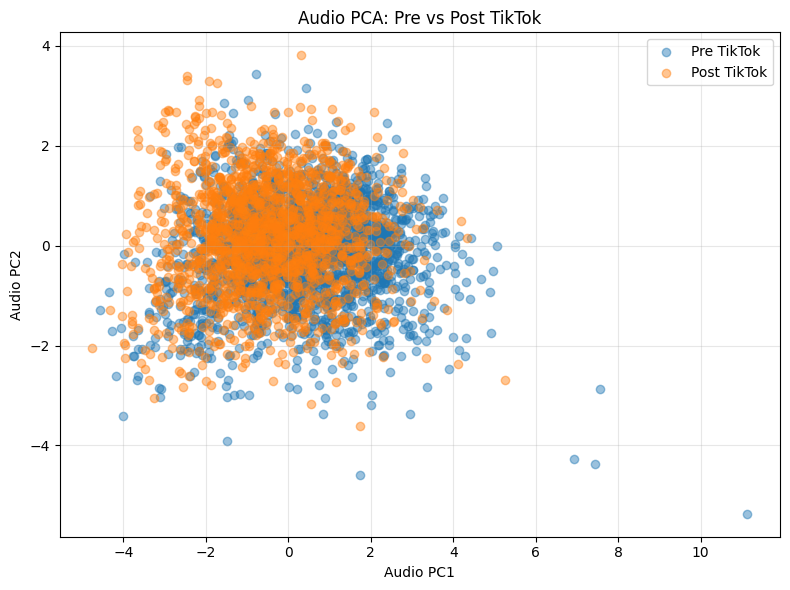

In [73]:
plt.figure(figsize=(8, 6))

for era in ["Pre TikTok", "Post TikTok"]:
    subset = audio_df[audio_df["audio_era"] == era]

    plt.scatter(
        subset["audio_PC1"],
        subset["audio_PC2"],
        alpha=0.45,
        label=era
    )

plt.xlabel("Audio PC1")
plt.ylabel("Audio PC2")
plt.title("Audio PCA: Pre vs Post TikTok")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

7. Choose K for Audio Clustering

In [74]:
for k in range(2, 8):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_audio_scaled)
    score = silhouette_score(X_audio_scaled, labels)

    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.245
k=3, silhouette=0.200
k=4, silhouette=0.182
k=5, silhouette=0.186
k=6, silhouette=0.183
k=7, silhouette=0.176


8. Audio Clustering

In [75]:
audio_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

audio_df["audio_cluster"] = audio_kmeans.fit_predict(X_audio_scaled)

audio_df["audio_cluster"].value_counts().sort_index()

audio_cluster
0    1720
1    1416
2     647
Name: count, dtype: int64

9. Audio Cluster Summary

In [76]:
audio_cluster_summary = (
    audio_df
    .groupby("audio_cluster")[audio_features]
    .mean()
    .round(2)
)

audio_cluster_summary

,valence,arousal,rms_loudness,spectral_centroid_mean,spectral_rolloff_mean,tempo_bpm_adjusted
audio_cluster,,,,,,
0,6.19,5.81,0.28,3589.86,1898.10,115.55
1,5.14,5.23,0.33,2794.71,1120.54,101.13
2,4.70,4.78,0.20,2276.75,1042.69,108.08


10. Audio Clusters on PCA Plot

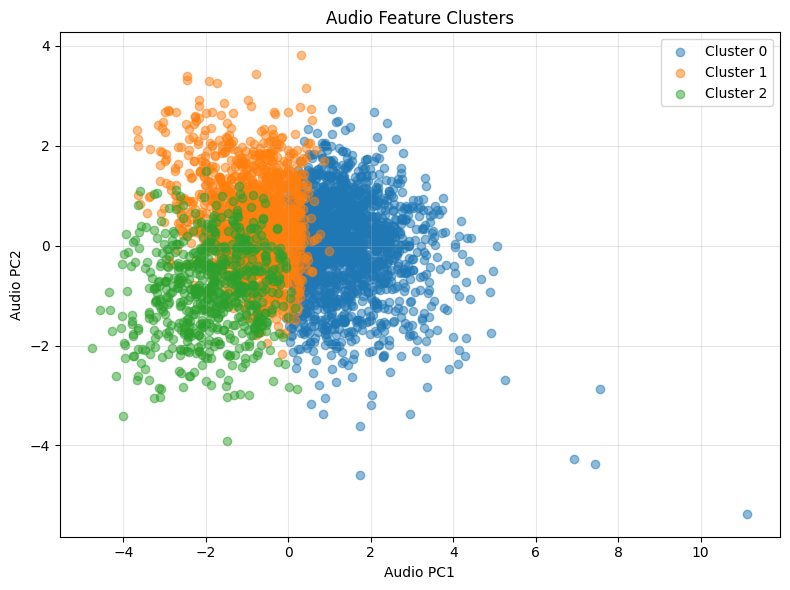

In [77]:
cluster_colors = {
    0: "tab:blue",
    1: "tab:orange",
    2: "tab:green"
}

plt.figure(figsize=(8, 6))

for cluster in sorted(audio_df["audio_cluster"].unique()):
    subset = audio_df[audio_df["audio_cluster"] == cluster]

    plt.scatter(
        subset["audio_PC1"],
        subset["audio_PC2"],
        color=cluster_colors[cluster],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Audio PC1")
plt.ylabel("Audio PC2")
plt.title("Audio Feature Clusters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

11. Audio Cluster Breakdown: Pre vs Post TikTok

In [78]:
audio_era_cluster_counts = pd.crosstab(
    audio_df["audio_era"],
    audio_df["audio_cluster"]
).loc[["Pre TikTok", "Post TikTok"]]

audio_era_cluster_counts

audio_cluster,0,1,2
audio_era,,,
Pre TikTok,1186,593,315
Post TikTok,534,823,332


In [79]:
audio_era_cluster_pct = (
    pd.crosstab(
        audio_df["audio_era"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
).loc[["Pre TikTok", "Post TikTok"]]

audio_era_cluster_pct.round(1)

audio_cluster,0,1,2
audio_era,,,
Pre TikTok,56.6,28.3,15.0
Post TikTok,31.6,48.7,19.7


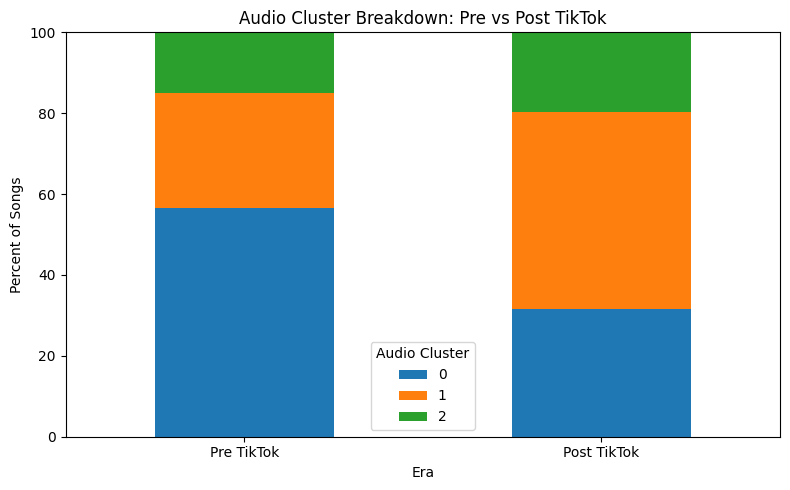

In [80]:
audio_era_cluster_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    color=[cluster_colors[c] for c in audio_era_cluster_pct.columns]
)

plt.xlabel("Era")
plt.ylabel("Percent of Songs")
plt.title("Audio Cluster Breakdown: Pre vs Post TikTok")
plt.legend(title="Audio Cluster")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

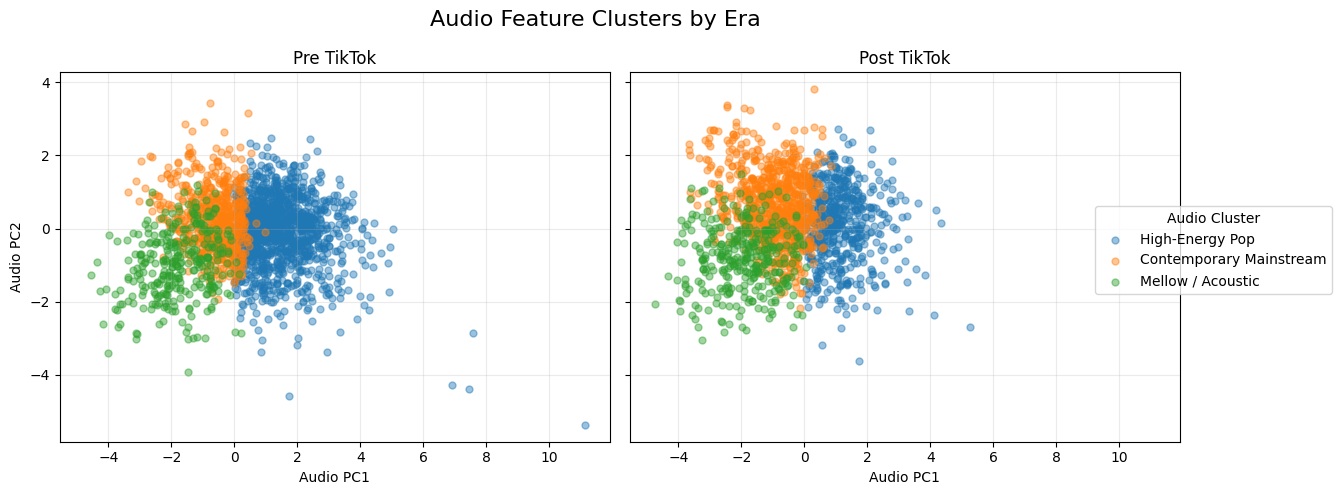

In [91]:
import matplotlib.pyplot as plt

# Cluster labels for readability
cluster_labels = {
    0: "High-Energy Pop",
    1: "Contemporary Mainstream",
    2: "Mellow / Acoustic"
}

# Make display label column
audio_df["audio_cluster_label"] = audio_df["audio_cluster"].map(cluster_labels)

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

eras = ["Pre TikTok", "Post TikTok"]

for ax, era in zip(axes, eras):
    era_df = audio_df[audio_df["audio_era"] == era]

    for cluster in sorted(era_df["audio_cluster"].unique()):
        subset = era_df[era_df["audio_cluster"] == cluster]

        ax.scatter(
            subset["audio_PC1"],
            subset["audio_PC2"],
            alpha=0.45,
            s=25,
            label=cluster_labels[cluster]
        )

    ax.set_title(era)
    ax.set_xlabel("Audio PC1")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Audio PC2")

# One shared legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Audio Cluster",
    loc="center right",
    bbox_to_anchor=(1.12, 0.5)
)

fig.suptitle("Audio Feature Clusters by Era", fontsize=16)

plt.tight_layout()

plt.savefig(
    "audio_pca_clusters_by_era.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Audio features to compare across eras
feature_cols = [
    "valence",
    "arousal",
    "rms_loudness",
    "spectral_centroid_mean",
    "tempo_bpm_adjusted"
]

# Calculate era means
feature_summary = (
    audio_df
    .groupby("audio_era")[feature_cols]
    .mean()
    .T
)

# Force order
feature_summary = feature_summary[["Pre TikTok", "Post TikTok"]]

# Calculate percent change
feature_summary["% Change"] = (
    (feature_summary["Post TikTok"] - feature_summary["Pre TikTok"])
    / feature_summary["Pre TikTok"]
    * 100
).round(1)

# Run Mann-Whitney tests for each feature
p_values = []

for feature in feature_cols:
    pre = audio_df.loc[audio_df["audio_era"] == "Pre TikTok", feature].dropna()
    post = audio_df.loc[audio_df["audio_era"] == "Post TikTok", feature].dropna()

    u, p = mannwhitneyu(pre, post, alternative="two-sided")
    p_values.append(p)

feature_summary["p-value"] = p_values

# Clean feature names for display
feature_summary = feature_summary.rename(index={
    "valence": "Valence",
    "arousal": "Arousal",
    "rms_loudness": "Loudness",
    "spectral_centroid_mean": "Brightness",
    "tempo_bpm_adjusted": "Tempo"
})

display(feature_summary.round(3))

audio_era,Pre TikTok,Post TikTok,% Change,p-value
Valence,5.749,5.292,-8.0,0.000
Arousal,5.478,5.334,-2.6,0.000
Loudness,0.275,0.298,8.3,0.000
Brightness,3231.770,2864.182,-11.4,0.000
Tempo,110.016,107.463,-2.3,0.001


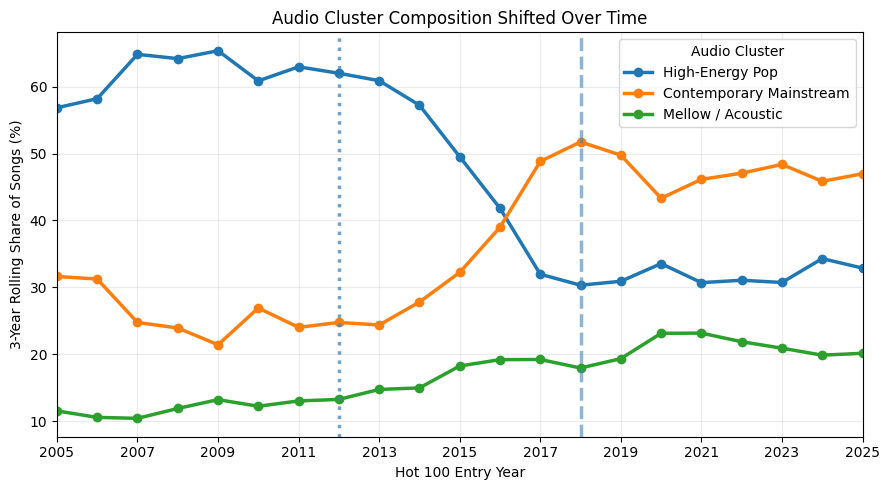

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Cluster labels
# -----------------------------
cluster_labels = {
    0: "High-Energy Pop",
    1: "Contemporary Mainstream",
    2: "Mellow / Acoustic"
}

# -----------------------------
# 2. Calculate yearly cluster percentages
# -----------------------------
cluster_year_pct = (
    pd.crosstab(
        audio_df["entry_year"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
)

# Rename cluster columns for readability
cluster_year_pct = cluster_year_pct.rename(columns=cluster_labels)

# Optional: remove incomplete 2026
cluster_year_pct = cluster_year_pct.loc[cluster_year_pct.index <= 2025]

# -----------------------------
# 3. Smooth with 3-year rolling average
# -----------------------------
cluster_year_pct_roll = (
    cluster_year_pct
    .rolling(
        window=3,
        center=True,
        min_periods=1
    )
    .mean()
)

# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(9, 5))

for cluster_name in cluster_year_pct_roll.columns:
    plt.plot(
        cluster_year_pct_roll.index,
        cluster_year_pct_roll[cluster_name],
        marker="o",
        linewidth=2.5,
        label=cluster_name
    )

# Streaming milestone line
plt.axvline(
    x=2012,
    linestyle=":",
    linewidth=2.5,
    color="steelblue",
    alpha=0.75
)

# TikTok milestone line
plt.axvline(
    x=2018,
    linestyle="--",
    linewidth=2.5,
    color="steelblue",
    alpha=0.6
)

# Labels and title
plt.xlabel("Hot 100 Entry Year")
plt.ylabel("3-Year Rolling Share of Songs (%)")
plt.title("Audio Cluster Composition Shifted Over Time")

# Clean x-axis
plt.xticks(range(2005, 2026, 2))
plt.xlim(2005, 2025)

# Grid and legend
plt.grid(True, alpha=0.25)
plt.legend(title="Audio Cluster")

plt.tight_layout()

# Poster-quality export
plt.savefig(
    "audio_cluster_composition_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

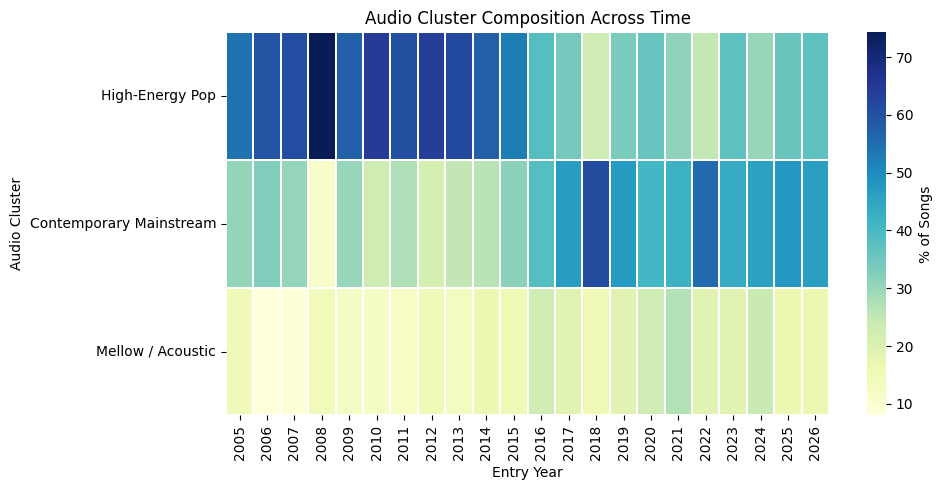

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cluster percentages by year
cluster_pct_year = (
    pd.crosstab(
        audio_df["entry_year"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
)

# Rename clusters
cluster_pct_year = cluster_pct_year.rename(columns={
    0: "High-Energy Pop",
    1: "Contemporary Mainstream",
    2: "Mellow / Acoustic"
})

plt.figure(figsize=(10,5))

sns.heatmap(
    cluster_pct_year.T,
    cmap="YlGnBu",
    cbar_kws={"label": "% of Songs"},
    linewidths=0.3
)

plt.title("Audio Cluster Composition Across Time")
plt.xlabel("Entry Year")
plt.ylabel("Audio Cluster")

plt.tight_layout()
plt.show()

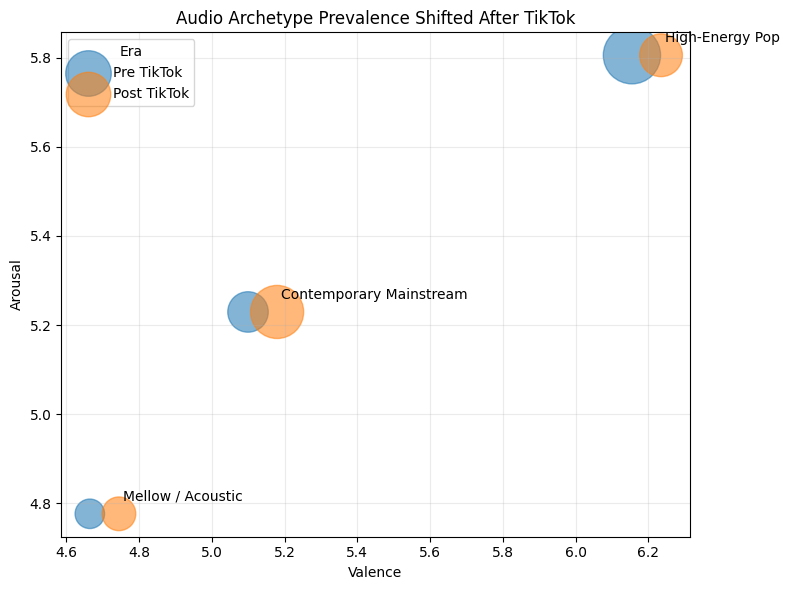

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Cluster labels
# -----------------------------
cluster_labels = {
    0: "High-Energy Pop",
    1: "Contemporary Mainstream",
    2: "Mellow / Acoustic"
}

# -----------------------------
# 2. Cluster centroids from audio features
# -----------------------------
cluster_centroids = (
    audio_df
    .groupby("audio_cluster")[
        ["valence", "arousal"]
    ]
    .mean()
    .reset_index()
)

cluster_centroids["cluster_label"] = cluster_centroids["audio_cluster"].map(cluster_labels)

# -----------------------------
# 3. Cluster share by era
# -----------------------------
cluster_share = (
    pd.crosstab(
        audio_df["audio_era"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
).reset_index()

cluster_share_long = cluster_share.melt(
    id_vars="audio_era",
    var_name="audio_cluster",
    value_name="share"
)

cluster_share_long["audio_cluster"] = cluster_share_long["audio_cluster"].astype(int)

# Merge centroid positions with era-specific shares
bubble_df = cluster_share_long.merge(
    cluster_centroids,
    on="audio_cluster",
    how="left"
)

# -----------------------------
# 4. Plot
# -----------------------------
plt.figure(figsize=(8, 6))

# Slight x-offset so Pre/Post bubbles don't perfectly overlap
era_offsets = {
    "Pre TikTok": -0.04,
    "Post TikTok": 0.04
}

for era in ["Pre TikTok", "Post TikTok"]:
    subset = bubble_df[bubble_df["audio_era"] == era].copy()

    plt.scatter(
        subset["valence"] + era_offsets[era],
        subset["arousal"],
        s=subset["share"] * 30,  # bubble size scaled by prevalence
        alpha=0.55,
        label=era
    )

# Cluster labels near centroid positions
for _, row in cluster_centroids.iterrows():
    plt.text(
        row["valence"] + 0.05,
        row["arousal"] + 0.03,
        row["cluster_label"],
        fontsize=10
    )

plt.xlabel("Valence")
plt.ylabel("Arousal")
plt.title("Audio Archetype Prevalence Shifted After TikTok")

plt.grid(True, alpha=0.25)
plt.legend(title="Era")

plt.tight_layout()

plt.savefig(
    "audio_cluster_bubble_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

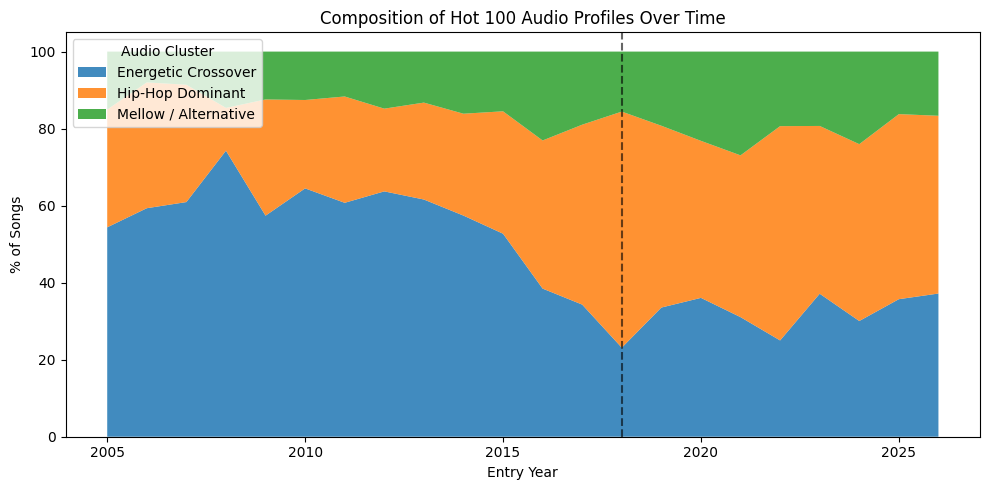

In [107]:
cluster_pct_year = (
    pd.crosstab(
        audio_df["entry_year"],
        audio_df["audio_cluster"],
        normalize="index"
    ) * 100
)

cluster_pct_year = cluster_pct_year.rename(columns={
    0: "Energetic Crossover",
    1: "Hip-Hop Dominant",
    2: "Mellow / Alternative"
})

plt.figure(figsize=(10,5))

plt.stackplot(
    cluster_pct_year.index,
    cluster_pct_year["Energetic Crossover"],
    cluster_pct_year["Hip-Hop Dominant"],
    cluster_pct_year["Mellow / Alternative"],
    labels=cluster_pct_year.columns,
    alpha=0.85
)

plt.axvline(
    2018,
    linestyle="--",
    color="black",
    alpha=0.6
)

plt.title("Composition of Hot 100 Audio Profiles Over Time")
plt.xlabel("Entry Year")
plt.ylabel("% of Songs")

plt.legend(
    title="Audio Cluster",
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Genres

In [99]:
genre_cols = [
    c for c in audio_df.columns
    if c.startswith("genre_family_")
]

cluster_genres = (
    audio_df
    .groupby("audio_cluster")[genre_cols]
    .mean()
    .T
    .round(3)
)

display(cluster_genres)

audio_cluster,0,1,2
genre_family_blues,0.008,0.008,0.038
genre_family_brass_and_military,0.001,0.000,0.001
genre_family_children_s,0.003,0.002,0.011
genre_family_classical,0.001,0.001,0.015
genre_family_electronic,0.619,0.341,0.405
genre_family_folk_world_and_country,0.042,0.041,0.170
genre_family_funk_soul,0.119,0.106,0.102
genre_family_hip_hop,0.388,0.963,0.317
genre_family_jazz,0.009,0.007,0.049
genre_family_latin,0.047,0.046,0.055


In [100]:
for cluster in cluster_genres.columns:
    print("\nCluster", cluster)
    print(cluster_genres[cluster].sort_values(ascending=False).head(5))


Cluster 0
genre_family_electronic    0.619
genre_family_rock          0.467
genre_family_hip_hop       0.388
genre_family_pop           0.288
genre_family_funk_soul     0.119
Name: 0, dtype: float64

Cluster 1
genre_family_hip_hop       0.963
genre_family_electronic    0.341
genre_family_rock          0.206
genre_family_pop           0.139
genre_family_funk_soul     0.106
Name: 1, dtype: float64

Cluster 2
genre_family_rock                      0.541
genre_family_electronic                0.405
genre_family_hip_hop                   0.317
genre_family_pop                       0.234
genre_family_folk_world_and_country    0.170
Name: 2, dtype: float64


In [102]:
genre_by_era = (
    audio_df
    .groupby("audio_era")[genre_cols]
    .mean()
    .T
)

genre_by_era

audio_era,Post TikTok,Pre TikTok
genre_family_blues,0.009656,0.016239
genre_family_brass_and_military,0.000524,0.000729
genre_family_children_s,0.003475,0.004618
genre_family_classical,0.003628,0.003713
genre_family_electronic,0.450487,0.500649
genre_family_folk_world_and_country,0.057345,0.068733
genre_family_funk_soul,0.090092,0.128936
genre_family_hip_hop,0.751859,0.461009
genre_family_jazz,0.011523,0.017603
genre_family_latin,0.054039,0.043450


<Axes: xlabel='audio_era'>

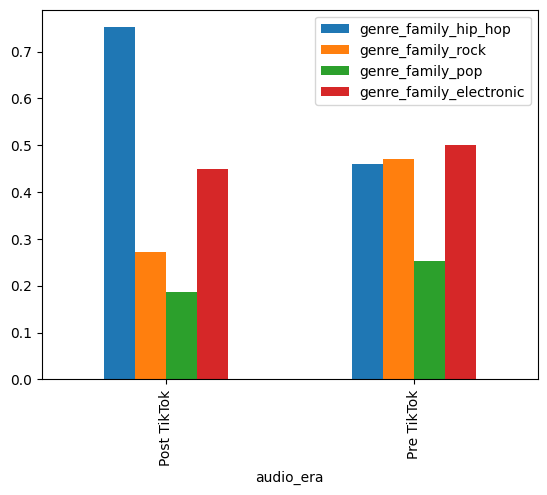

In [105]:
audio_df.groupby("audio_era")[
    ["genre_family_hip_hop",
     "genre_family_rock",
     "genre_family_pop",
     "genre_family_electronic"]
].mean().round(3).plot.bar()

12. Audio Clusters vs Billboard Outcomes

In [81]:
audio_billboard_summary = (
    audio_df
    .groupby("audio_cluster")[
        [
            "peak_rank",
            "total_weeks",
            "top10_weeks",
            "top40_weeks",
            "time_to_peak"
        ]
    ]
    .mean()
    .round(2)
)

audio_billboard_summary

,peak_rank,total_weeks,top10_weeks,top40_weeks,time_to_peak
audio_cluster,,,,,
0,17.82,21.14,3.38,12.76,12.03
1,19.00,17.99,2.65,10.38,8.02
2,20.96,17.58,1.92,9.23,16.29


13. Sample Songs From Each Audio Cluster

In [84]:
life_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

life_df["life_cluster"] = life_kmeans.fit_predict(X_life_scaled)

print(life_df["life_cluster"].value_counts().sort_index())
print("life_cluster" in life_df.columns)

life_cluster
0     935
1    3109
2      34
Name: count, dtype: int64
True


In [85]:
print("audio_cluster" in audio_df.columns)
print("life_cluster" in life_df.columns)

True
True


In [86]:
audio_df["audio_cluster"].value_counts(normalize=True) * 100

audio_cluster
0    45.466561
1    37.430611
2    17.102828
Name: proportion, dtype: float64

In [87]:
life_df["life_cluster"].value_counts(normalize=True) * 100

life_cluster
1    76.238352
0    22.927906
2     0.833742
Name: proportion, dtype: float64

In [88]:
for cluster in sorted(audio_df["audio_cluster"].unique()):
    print("\n" + "=" * 60)
    print(f"AUDIO CLUSTER {cluster}")
    print("=" * 60)

    display(
        audio_df[audio_df["audio_cluster"] == cluster][
            [
                "Song",
                "Artist",
                "valence",
                "arousal",
                "rms_loudness",
                "spectral_centroid_mean",
                "tempo_bpm_adjusted"
            ]
        ].sample(
            n=min(15, len(audio_df[audio_df["audio_cluster"] == cluster])),
            random_state=42
        )
    )


AUDIO CLUSTER 0


,Song,Artist,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
1463,Heart Attack,Demi Lovato,5.884053,5.805308,0.231632,4238.966850,172.265549
3578,Tombstone,Rod Wave,5.546264,5.470427,0.266422,3169.153137,84.430611
301,BOP,DaBaby,5.775549,5.494606,0.362072,3753.357481,127.034439
340,Bad Day,Daniel Powter,5.379387,5.804925,0.233370,3142.064130,140.147247
793,Cruel Summer,Taylor Swift,6.458718,5.671692,0.260883,2963.422738,85.068542
1671,I Know You Want Me (Calle Ocho),Pitbull,6.757876,5.579319,0.282817,3002.341960,126.792923
3453,The Heart Part 4,Kendrick Lamar,5.423228,5.802316,0.218903,4071.320623,97.809319
563,Break Up In A Small Town,Sam Hunt,5.756688,5.264492,0.260763,4170.062762,89.672150
3909,Who Knew,P!nk,5.468628,5.974624,0.242280,3657.008920,140.083252
2105,Loser Like Me,Glee Cast,7.646956,5.827900,0.302064,4441.976211,105.816521



AUDIO CLUSTER 1


,Song,Artist,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
2388,N.H.I.E.,21 Savage & Doja Cat,4.865159,4.985857,0.480974,1620.909680,132.048813
2675,Pink Skies,Zach Bryan,5.021434,5.047755,0.263186,2560.767171,84.624451
970,Down Bad,Taylor Swift,5.401105,5.966967,0.267660,2589.778834,79.470116
545,Boy With Luv,BTS Featuring Halsey,5.588244,5.454425,0.227866,2781.976760,118.717636
571,Bright,Echosmith,5.099182,5.149970,0.246895,2656.316046,89.980484
2297,Moment 4 Life,Nicki Minaj Featuring Drake,5.535745,5.075954,0.355638,3508.942536,98.122368
1480,Heaven,Kane Brown,4.905485,5.233827,0.247564,2520.744303,80.798622
171,Ahhh Ha,Lil Durk,3.970793,5.244531,0.370111,2705.171949,104.039421
2874,Rock Yo Hips,Crime Mob Featuring Lil Scrappy,5.555298,4.807736,0.305362,3268.242187,77.324570
125,8am In Charlotte,Drake,4.440627,4.738479,0.270456,3185.117056,78.918808



AUDIO CLUSTER 2


,Song,Artist,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
4028,You Should Probably Leave,Chris Stapleton,4.874928,5.258160,0.214124,1968.647676,91.874100
1423,Hallelujah,Matthew Schuler,4.060286,4.282128,0.180619,1914.464979,104.264351
2691,Please Come Home For Christmas,Eagles,5.032470,4.829657,0.112487,2038.744474,91.228203
2700,Poker Face,Glee Cast,4.698187,5.096776,0.125828,2307.241900,92.285156
505,Blue,Billie Eilish,5.245200,4.722973,0.300440,1543.977680,105.231026
2769,Purple Rain,Prince And The Revolution,4.818000,4.816129,0.170159,3038.283032,112.306931
1196,Florida!!!,Taylor Swift Featuring Florence + The Machine,4.573282,4.279164,0.204035,2005.533108,75.238655
876,Devil Don't Know,Morgan Wallen,4.312094,4.579465,0.182416,2025.038426,124.951683
1484,Hell At Night,BigXthaPlug Featuring Ella Langley,4.750645,5.046851,0.116181,2134.032038,75.502937
1756,I'm Yours,Jason Mraz,4.772732,5.183208,0.187415,2172.159945,75.502480


In [89]:
audio_era_cluster_pct.round(2)

audio_cluster,0,1,2
audio_era,,,
Pre TikTok,56.64,28.32,15.04
Post TikTok,31.62,48.73,19.66


In [90]:
audio_df.groupby("audio_cluster")[
    [
        "valence",
        "arousal",
        "rms_loudness",
        "spectral_centroid_mean",
        "tempo_bpm_adjusted"
    ]
].mean().round(2)

,valence,arousal,rms_loudness,spectral_centroid_mean,tempo_bpm_adjusted
audio_cluster,,,,,
0,6.19,5.81,0.28,3589.86,115.55
1,5.14,5.23,0.33,2794.71,101.13
2,4.70,4.78,0.20,2276.75,108.08


# CLEAN LIFECYLE CLUSTERING

14. Use Billboard-Only Lifecycle Features

In [20]:
lifecycle_features = [
    "peak_rank",
    "total_weeks",
    "top10_weeks",
    "top40_weeks",
    "time_to_peak"
]

life_df = df.dropna(subset=lifecycle_features + ["billboard_era"]).copy()

life_df["peak_success"] = 101 - life_df["peak_rank"]

cluster_features = [
    "peak_success",
    "total_weeks",
    "top10_weeks",
    "top40_weeks",
    "time_to_peak"
]

print(life_df.shape)
life_df[cluster_features].describe()

(4078, 58)


,peak_success,total_weeks,top10_weeks,top40_weeks,time_to_peak
count,4078.000000,4078.000000,4078.000000,4078.000000,4078.000000
mean,81.937469,18.942619,2.734183,10.936734,10.864885
std,12.072131,13.284685,6.320130,12.105129,36.439589
min,61.000000,1.000000,0.000000,1.000000,0.000000
25%,72.000000,7.000000,0.000000,1.000000,0.000000
50%,82.000000,20.000000,0.000000,6.000000,4.000000
75%,93.000000,25.000000,1.000000,17.000000,12.000000
max,100.000000,112.000000,80.000000,94.000000,681.000000


15. Standardize Lifecycle Features

In [21]:
life_scaler = StandardScaler()

X_life = life_df[cluster_features]
X_life_scaled = life_scaler.fit_transform(X_life)

16. Choose K for Lifecycle Clustering

In [22]:
for k in range(2, 8):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_life_scaled)
    score = silhouette_score(X_life_scaled, labels)

    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.510
k=3, silhouette=0.505
k=4, silhouette=0.379
k=5, silhouette=0.345
k=6, silhouette=0.355
k=7, silhouette=0.374


17. Lifecycle Clustering

In [23]:
life_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

life_df["lifecycle_cluster"] = life_kmeans.fit_predict(X_life_scaled)

life_df["lifecycle_cluster"].value_counts().sort_index()

lifecycle_cluster
0     935
1    3109
2      34
Name: count, dtype: int64

18. Lifecycle Cluster Summary

In [24]:
life_cluster_summary = (
    life_df
    .groupby("lifecycle_cluster")[
        [
            "peak_rank",
            "total_weeks",
            "top10_weeks",
            "top40_weeks",
            "time_to_peak"
        ]
    ]
    .median()
    .round(2)
)

life_cluster_summary

,peak_rank,total_weeks,top10_weeks,top40_weeks,time_to_peak
lifecycle_cluster,,,,,
0,4.0,32.0,10.0,26.0,11.0
1,24.0,17.0,0.0,3.0,1.0
2,14.0,31.5,0.0,25.0,263.5


19. Lifecycle PCA for Visualization

In [26]:
life_pca_model = PCA(n_components=2)

life_pcs = life_pca_model.fit_transform(X_life_scaled)

life_df["life_PC1"] = life_pcs[:, 0]
life_df["life_PC2"] = life_pcs[:, 1]

print("Life PC1 explained:", round(life_pca_model.explained_variance_ratio_[0] * 100, 2), "%")
print("Life PC2 explained:", round(life_pca_model.explained_variance_ratio_[1] * 100, 2), "%")
print("Total explained:", round(life_pca_model.explained_variance_ratio_.sum() * 100, 2), "%")

Life PC1 explained: 61.52 %
Life PC2 explained: 19.87 %
Total explained: 81.38 %


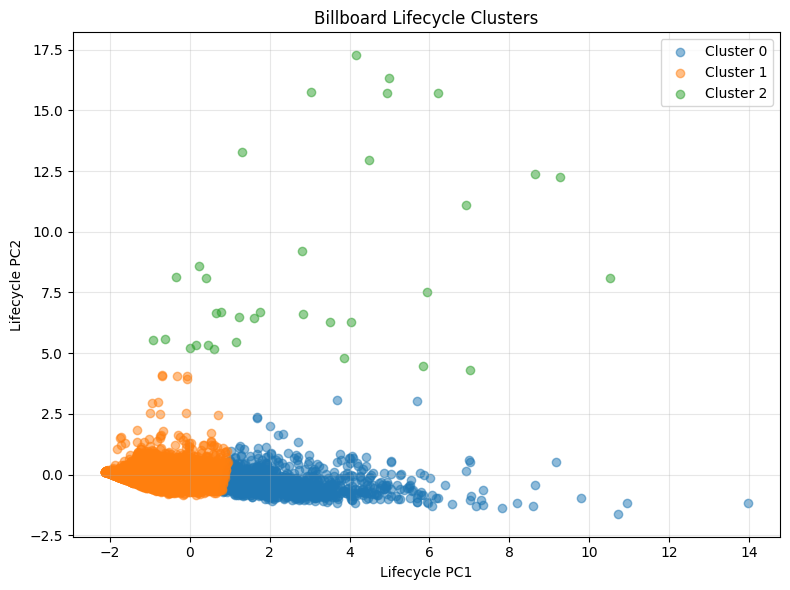

In [27]:
plt.figure(figsize=(8, 6))

for cluster in sorted(life_df["lifecycle_cluster"].unique()):
    subset = life_df[life_df["lifecycle_cluster"] == cluster]

    plt.scatter(
        subset["life_PC1"],
        subset["life_PC2"],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Lifecycle PC1")
plt.ylabel("Lifecycle PC2")
plt.title("Billboard Lifecycle Clusters")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

20. Lifecycle Cluster Breakdown: Pre vs Post TikTok

In [28]:
life_era_cluster_pct = (
    pd.crosstab(
        life_df["billboard_era"],
        life_df["lifecycle_cluster"],
        normalize="index"
    ) * 100
).loc[["Pre TikTok", "Post TikTok"]]

life_era_cluster_pct.round(1)

lifecycle_cluster,0,1,2
billboard_era,,,
Pre TikTok,29.2,70.1,0.6
Post TikTok,15.8,83.2,1.0


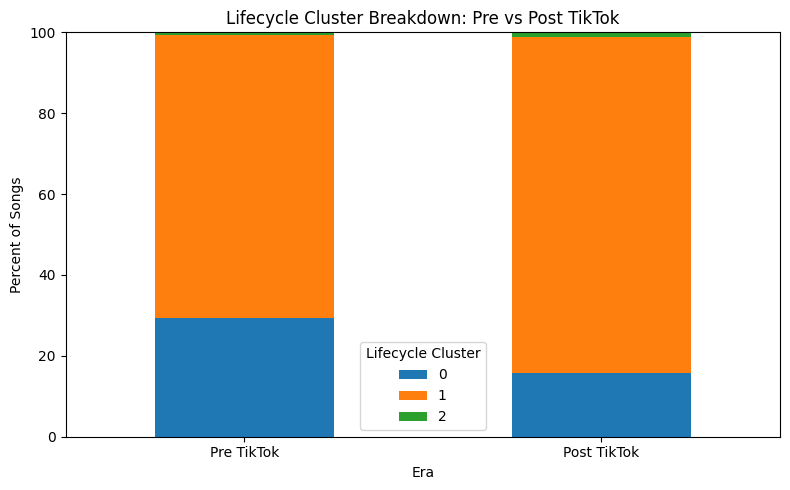

In [29]:
life_era_cluster_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.xlabel("Era")
plt.ylabel("Percent of Songs")
plt.title("Lifecycle Cluster Breakdown: Pre vs Post TikTok")
plt.legend(title="Lifecycle Cluster")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
audio_df.to_csv("audio_cluster_results.csv", index=False)
life_df.to_csv("lifecycle_cluster_results.csv", index=False)

audio_cluster_summary.to_csv("audio_cluster_summary.csv")
life_cluster_summary.to_csv("lifecycle_cluster_summary.csv")

# Editing df because of bad release dates

In [35]:
bad_dates = df[
    (df["days_release_to_chart"] < 0) |
    (df["days_release_to_peak"] < 0)
].copy()

print("Negative date rows:", len(bad_dates))

Negative date rows: 294


In [36]:
bad_dates[
    [
        "Song",
        "Artist",
        "matched_song",
        "matched_artist",
        "days_release_to_chart",
        "days_release_to_peak",
        "apple_release_date",
        "first_chart_date",
        "match_score",
        "usable_match_v2",
        "recovery_reason"
    ]
].sort_values("days_release_to_chart")

,Song,Artist,matched_song,matched_artist,days_release_to_chart,days_release_to_peak,apple_release_date,first_chart_date,match_score,usable_match_v2,recovery_reason
2512,O,Omarion,O (Mixed),Omarion,-7416.0,-7360.0,2025-05-09 12:00:00,2005-01-19,1.000000,True,NaN
2763,Pullin' Me Back,Chingy Featuring Tyrese,Pullin' Me Back (feat. Tyrese) [Mixed],Chingy,-7020.0,-6922.0,2025-09-15 12:00:00,2006-06-28,1.000000,True,NaN
559,Break It Off,Rihanna & Sean Paul,Break It Off (Mixed),Sean Paul & Rihanna,-6954.0,-6856.0,2025-12-19 12:00:00,2006-12-06,0.875000,True,NaN
3385,Tell Me When To Go,E-40 Featuring Keak Da Sneak,Tell Me When To Go (feat. Keak Da Sneak) [Mixed],E-40,-6871.0,-6843.0,2024-12-21 12:00:00,2006-03-01,1.000000,True,NaN
1449,Hate It Or Love It,The Game Featuring 50 Cent,Hate It or Love It (feat. 50 Cent) [Mixed],The Game,-6751.0,-6688.0,2023-08-04 12:00:00,2005-02-09,1.000000,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1292,Gimme More,Britney Spears,Gimme More (Remastered),Britney Spears,-2.0,19.0,2007-09-20 12:00:00,2007-09-19,1.000000,True,NaN
2878,Rockin' That Thang,The-Dream,Rockin' That Thang,The-Dream,-2.0,82.0,2009-01-01 12:00:00,2008-12-31,1.000000,True,NaN
751,Come See Me,Rod Wave,Come See Me,Rod Wave,-2.0,12.0,2023-09-14 12:00:00,2023-09-13,1.000000,True,NaN
1785,Imma Be,The Black Eyed Peas,Imma Be,Black Eyed Peas,-1.0,272.0,2009-06-03 12:00:00,2009-06-03,0.964706,True,NaN


In [37]:
bad_dates.sort_values(
    "days_release_to_chart"
)[
    [
        "Song",
        "Artist",
        "matched_song",
        "matched_artist",
        "days_release_to_chart",
        "match_score"
    ]
].head(50)

,Song,Artist,matched_song,matched_artist,days_release_to_chart,match_score
2512,O,Omarion,O (Mixed),Omarion,-7416.0,1.000000
2763,Pullin' Me Back,Chingy Featuring Tyrese,Pullin' Me Back (feat. Tyrese) [Mixed],Chingy,-7020.0,1.000000
559,Break It Off,Rihanna & Sean Paul,Break It Off (Mixed),Sean Paul & Rihanna,-6954.0,0.875000
3385,Tell Me When To Go,E-40 Featuring Keak Da Sneak,Tell Me When To Go (feat. Keak Da Sneak) [Mixed],E-40,-6871.0,1.000000
1449,Hate It Or Love It,The Game Featuring 50 Cent,Hate It or Love It (feat. 50 Cent) [Mixed],The Game,-6751.0,1.000000
3049,Show Me What You Got,Jay-Z,Show Me What You Got (Mixed),JAY-Z,-6722.0,1.000000
290,Ayo Technology,50 Cent Featuring Justin Timberlake & Timbaland,Ayo Technology (feat. Justin Timberlake) [Mixed],50 Cent,-6674.0,1.000000
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,"1, 2 Step (feat. Missy Elliott) [Mixed]",Ciara,-6639.0,1.000000
2180,Luxurious,Gwen Stefani,Luxurious (Mixed),Gwen Stefani,-6541.0,1.000000
3657,U Make Me Wanna,Jadakiss Featuring Mariah Carey,U Make Me Wanna (feat. Mariah Carey) [Mixed],Jadakiss,-6513.0,1.000000


In [38]:
df["days_release_to_chart"].describe()

count     3783.000000
mean       292.312186
std       2287.195916
min      -7416.000000
25%         11.000000
50%         14.000000
75%         71.000000
max      27422.000000
Name: days_release_to_chart, dtype: float64

In [41]:
(df["days_release_to_chart"] < 0).sum()

np.int64(294)

In [40]:
(df["days_release_to_chart"] < -30).sum()

np.int64(214)

In [42]:
(df["days_release_to_chart"] < -180).sum()

np.int64(127)

In [43]:
df["matched_song"].str.contains(
    "Mixed",
    case=False,
    na=False
).sum()

np.int64(75)

In [47]:
df["matched_song"].str.contains(
    "mixed|remaster|reworked",
    case=False,
    na=False
).sum()

np.int64(88)

In [44]:
mixed_mask = df["matched_song"].str.contains(
    "mixed|remaster|reworked",
    case=False,
    na=False
)

In [45]:
df_clean = df.loc[~mixed_mask].copy()

In [46]:
(df_clean["days_release_to_chart"] < 0).sum()

np.int64(217)

In [53]:
bad_dates.sort_values("days_release_to_chart")[
    [
        "Song",
        "Artist",
        "matched_song",
        "matched_artist",
        "apple_release_date",
        "first_chart_date",
        "days_release_to_chart",
        "match_score"
    ]
].head(100)

,Song,Artist,matched_song,matched_artist,apple_release_date,first_chart_date,days_release_to_chart,match_score
2512,O,Omarion,O (Mixed),Omarion,2025-05-09 12:00:00,2005-01-19,-7416.0,1.000000
2763,Pullin' Me Back,Chingy Featuring Tyrese,Pullin' Me Back (feat. Tyrese) [Mixed],Chingy,2025-09-15 12:00:00,2006-06-28,-7020.0,1.000000
559,Break It Off,Rihanna & Sean Paul,Break It Off (Mixed),Sean Paul & Rihanna,2025-12-19 12:00:00,2006-12-06,-6954.0,0.875000
3385,Tell Me When To Go,E-40 Featuring Keak Da Sneak,Tell Me When To Go (feat. Keak Da Sneak) [Mixed],E-40,2024-12-21 12:00:00,2006-03-01,-6871.0,1.000000
1449,Hate It Or Love It,The Game Featuring 50 Cent,Hate It or Love It (feat. 50 Cent) [Mixed],The Game,2023-08-04 12:00:00,2005-02-09,-6751.0,1.000000
3049,Show Me What You Got,Jay-Z,Show Me What You Got (Mixed),JAY-Z,2025-03-13 12:00:00,2006-10-18,-6722.0,1.000000
290,Ayo Technology,50 Cent Featuring Justin Timberlake & Timbaland,Ayo Technology (feat. Justin Timberlake) [Mixed],50 Cent,2025-11-28 12:00:00,2007-08-22,-6674.0,1.000000
1,"""1, 2 Step""",Ciara Featuring Missy Elliott,"1, 2 Step (feat. Missy Elliott) [Mixed]",Ciara,2023-03-10 12:00:00,2005-01-05,-6639.0,1.000000
2180,Luxurious,Gwen Stefani,Luxurious (Mixed),Gwen Stefani,2023-09-29 12:00:00,2005-11-02,-6541.0,1.000000
3657,U Make Me Wanna,Jadakiss Featuring Mariah Carey,U Make Me Wanna (feat. Mariah Carey) [Mixed],Jadakiss,2022-11-04 12:00:00,2005-01-05,-6513.0,1.000000


In [55]:
release_df = df[
    df["days_release_to_chart"] >= 0
].copy()

audio_df = df.copy()